In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import random
import zipfile
import shutil

In [3]:
# Setup
DATASET_ZIP = "/kaggle/input/datasets/kriszzz1/asl-dynamic-dataset/ASL_dynamic.zip"
MODEL_PATH = "/kaggle/input/datasets/kriszzz1/asl-task-1-model/best_model.pth"

# Extract dataset
DATASET_PATH = "/kaggle/input/datasets/kriszzz1/asl-dynamic-dataset/ASL_dynamic"
MODEL_PATH = "/kaggle/input/datasets/kriszzz1/asl-task-1-model/best_model.pth"

print("Dataset path:", DATASET_PATH)
print("Model path:", MODEL_PATH)

Dataset path: /kaggle/input/datasets/kriszzz1/asl-dynamic-dataset/ASL_dynamic
Model path: /kaggle/input/datasets/kriszzz1/asl-task-1-model/best_model.pth


In [4]:
# CNN Architecture
class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // 16),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // 16, in_channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        attn = self.gap(x).view(b, c)
        attn = self.fc(attn).view(b, c, 1, 1)
        return x * attn.expand_as(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, 
                                   stride=stride, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.attention = SpatialAttention(out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        identity = x
        out = self.depthwise(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.pointwise(out)
        out = self.bn2(out)
        out = self.attention(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class ASLResNeXt(nn.Module):
    def __init__(self, num_classes=26):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.stage2 = self._make_stage(64, 64, 2, stride=1)
        self.stage3 = self._make_stage(64, 128, 2, stride=2)
        self.stage4 = self._make_stage(128, 256, 2, stride=2)
        self.stage5 = self._make_stage(256, 512, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)
    
    def _make_stage(self, in_channels, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [ResidualBlock(in_channels, out_channels, stride, downsample)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x
    
    def extract_features(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

In [5]:
# Loading and freezing
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

cnn_backbone = ASLResNeXt(num_classes=26).to(device)
cnn_backbone.load_state_dict(torch.load(MODEL_PATH, map_location=device))

for param in cnn_backbone.parameters():
    param.requires_grad = False

cnn_backbone.eval()
print("CNN loaded and frozen")

Device: cuda
CNN loaded and frozen


In [6]:
# Creating dataset and augmenting
class AugmentedVideoDataset(Dataset):
    def __init__(self, root_dir, num_frames=16, mode='train'):
        self.root_dir = root_dir
        self.num_frames = num_frames
        self.mode = mode
        
        all_classes = sorted([d for d in os.listdir(root_dir) 
                             if os.path.isdir(os.path.join(root_dir, d))])
        self.classes = [c for c in all_classes if c != 'S']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        
        self.video_folders = []
        self.labels = []
        
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            folders = [f for f in os.listdir(cls_path) 
                      if os.path.isdir(os.path.join(cls_path, f))]
            
            for folder in folders:
                self.video_folders.append(os.path.join(cls_path, folder))
                self.labels.append(self.class_to_idx[cls])
        
        self.aug_factor = 10 if mode == 'train' else 1
        print(f"[{mode}] {len(self.video_folders)} sequences × {self.aug_factor} = {len(self)} samples")
    
    def __len__(self):
        return len(self.video_folders) * self.aug_factor
    
    def __getitem__(self, idx):
        real_idx = idx % len(self.video_folders)
        aug_idx = idx // len(self.video_folders)
        
        folder_path = self.video_folders[real_idx]
        label = self.labels[real_idx]
        
        frame_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.jpg')])
        total_frames = len(frame_files)
        
        # Temporal sampling strategies
        if self.mode == 'train':
            if aug_idx % 3 == 0:
                start = random.randint(0, max(0, total_frames - self.num_frames * 3))
                end = min(start + total_frames // 2, total_frames - 1)
                indices = np.linspace(start, end, self.num_frames, dtype=int)
            elif aug_idx % 3 == 1:
                step = max(1, total_frames // (self.num_frames + 5))
                indices = np.arange(0, min(self.num_frames * step, total_frames), step)[:self.num_frames]
            else:
                mid = total_frames // 2
                half_window = self.num_frames // 2
                start = max(0, mid - half_window * 2)
                end = min(total_frames - 1, mid + half_window * 2)
                indices = np.linspace(start, end, self.num_frames, dtype=int)
        else:
            indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        
        frames = []
        for i in indices:
            frame_path = os.path.join(folder_path, frame_files[min(i, len(frame_files)-1)])
            img = Image.open(frame_path).convert('RGB')
            
            if self.mode == 'train':
                left = random.randint(60, 100) if aug_idx % 2 == 0 else 80
                top = random.randint(0, 20) if aug_idx % 2 == 0 else 0
                img = img.crop((left, top, left + 480, top + 480))
                
                if aug_idx % 5 < 3:
                    from PIL import ImageEnhance
                    enhancer = ImageEnhance.Brightness(img)
                    img = enhancer.enhance(random.uniform(0.8, 1.2))
                    enhancer = ImageEnhance.Contrast(img)
                    img = enhancer.enhance(random.uniform(0.8, 1.2))
            else:
                left = (640 - 480) // 2
                img = img.crop((left, 0, left + 480, 480))
            
            img = img.resize((128, 128))
            img = transforms.functional.to_tensor(img)
            img = transforms.functional.normalize(img, 
                                                 mean=[0.485, 0.456, 0.406],
                                                 std=[0.229, 0.224, 0.225])
            frames.append(img)
        
        frames = torch.stack(frames)
        return frames, label

# Create datasets
train_dataset = AugmentedVideoDataset(DATASET_PATH, num_frames=16, mode='train')
val_dataset = AugmentedVideoDataset(DATASET_PATH, num_frames=16, mode='val')

# Split
total_videos = len(train_dataset.video_folders)
indices = list(range(total_videos))
random.seed(42)
random.shuffle(indices)

train_split = int(0.8 * total_videos)
train_indices = indices[:train_split]
val_indices = indices[train_split:]

train_dataset.video_folders = [train_dataset.video_folders[i] for i in train_indices]
train_dataset.labels = [train_dataset.labels[i] for i in train_indices]
val_dataset.video_folders = [val_dataset.video_folders[i] for i in val_indices]
val_dataset.labels = [val_dataset.labels[i] for i in val_indices]

print(f"Split: Train={len(train_indices)}, Val={len(val_indices)}")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

[train] 290 sequences × 10 = 2900 samples
[val] 290 sequences × 1 = 290 samples
Split: Train=232, Val=58


In [7]:
# Model
class CNNLSTM(nn.Module):
    def __init__(self, cnn_backbone, num_classes=30):
        super().__init__()
        self.cnn = cnn_backbone
        
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=128,
            num_layers=1,
            batch_first=True,
            bidirectional=False
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)
        )
        
        for m in self.fc.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        batch_size, num_frames, C, H, W = x.size()
        
        cnn_features = []
        for t in range(num_frames):
            frame = x[:, t, :, :, :]
            with torch.no_grad():
                features = self.cnn.extract_features(frame)
            cnn_features.append(features)
        
        cnn_features = torch.stack(cnn_features, dim=1)
        lstm_out, _ = self.lstm(cnn_features)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        
        return output

model = CNNLSTM(cnn_backbone, num_classes=len(train_dataset.classes)).to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,}, Total: {total:,}")

Trainable: 338,910, Total: 1,198,320


In [8]:
# Training
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

best_acc = 0.0
patience_counter = 0

for epoch in range(60):
    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for frames, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        frames, labels = frames.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    train_acc = 100. * train_correct / train_total
    
    # Validate
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for frames, labels in val_loader:
            frames, labels = frames.to(device), labels.to(device)
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * val_correct / val_total
    scheduler.step()
    
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}% | '
          f'LR={optimizer.param_groups[0]["lr"]:.6f}')
    
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), '/kaggle/working/best_lstm_model.pth')
        print(f'  ✓ Best: {val_acc:.2f}%')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= 15:
        print(f'Early stopping at epoch {epoch+1}')
        break

print(f"Training Complete - Best Accuracy: {best_acc:.2f}%")

torch.save(model.state_dict(), '/kaggle/working/final_lstm_model.pth')
print("\nModels saved to /kaggle/working/")
print("Download tab →")


Epoch 1: 100%|██████████| 145/145 [02:56<00:00,  1.22s/it]


Epoch 1: Train Acc=4.66% | Val Acc=15.52% | LR=0.000098
  ✓ Best: 15.52%


Epoch 2: 100%|██████████| 145/145 [02:39<00:00,  1.10s/it]


Epoch 2: Train Acc=10.00% | Val Acc=10.34% | LR=0.000090


Epoch 3: 100%|██████████| 145/145 [02:34<00:00,  1.07s/it]


...

Epoch 56: Train Acc=89.27% | Val Acc=72.41% | LR=0.000027


Epoch 57: 100%|██████████| 145/145 [02:31<00:00,  1.05s/it]


Epoch 57: Train Acc=87.97% | Val Acc=72.41% | LR=0.000024


Epoch 58: 100%|██████████| 145/145 [02:32<00:00,  1.05s/it]


Epoch 58: Train Acc=88.71% | Val Acc=75.86% | LR=0.000021
Early stopping at epoch 58
Training Complete - Best Accuracy: 81.03%

Models saved to /kaggle/working/
Download tab →


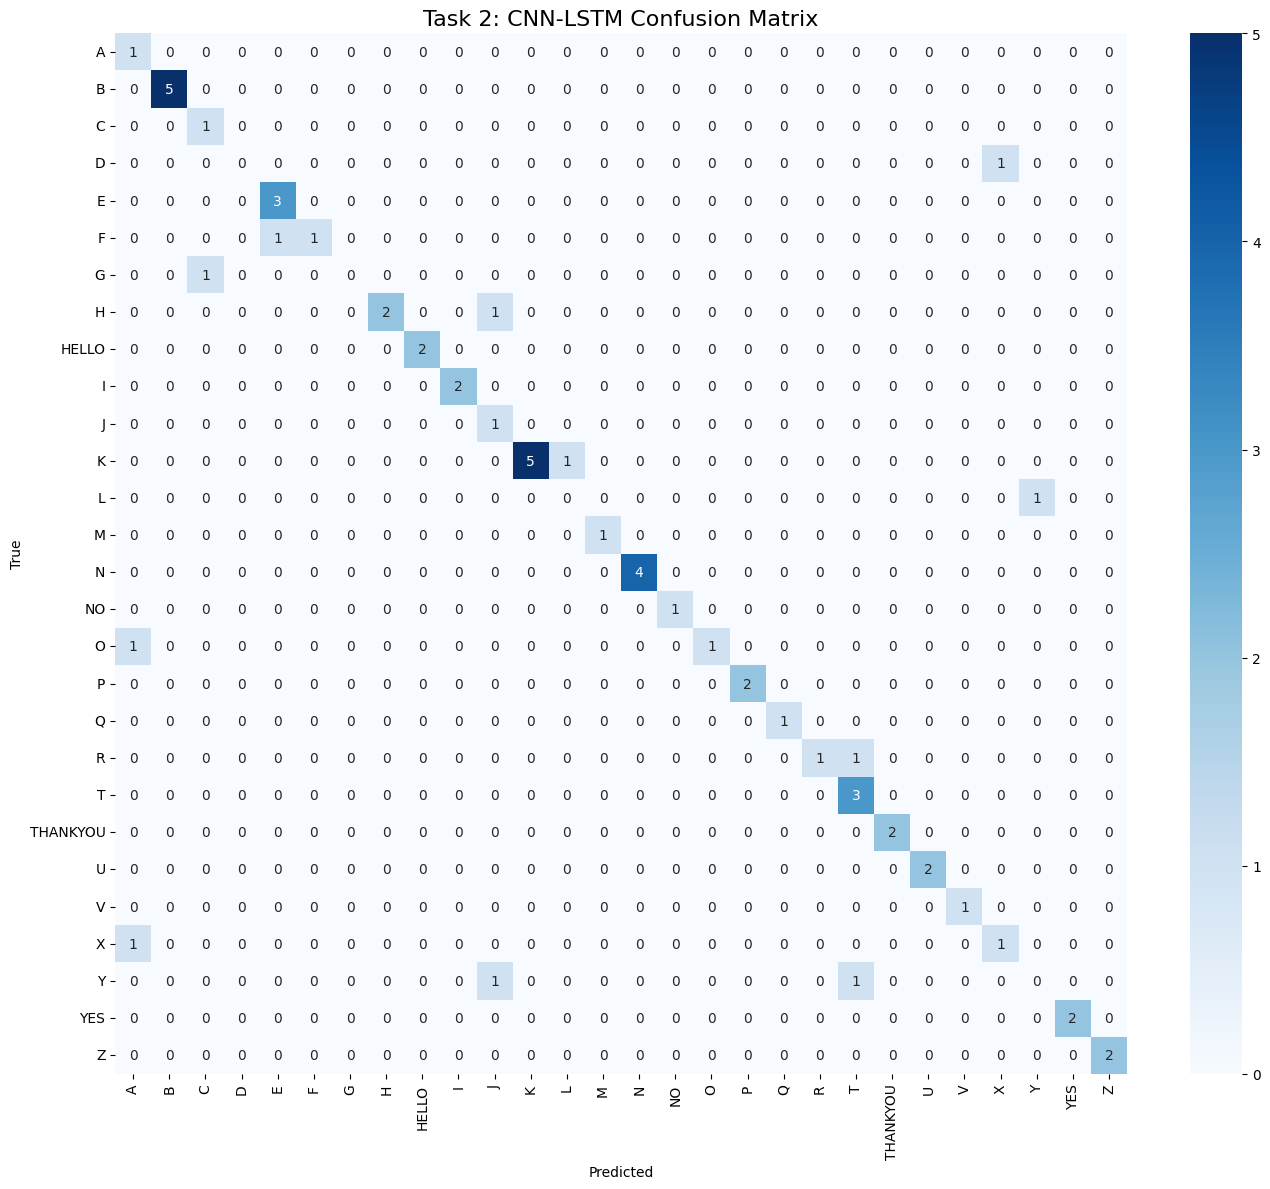

Saved confusion_matrix_task2.png

Per-Class Accuracy (28 classes in validation):
A           : 100.0%
B           : 100.0%
C           : 100.0%
D           :   0.0%
E           : 100.0%
F           :  50.0%
G           :   0.0%
H           :  66.7%
HELLO       : 100.0%
I           : 100.0%
J           : 100.0%
K           :  83.3%
L           :   0.0%
M           : 100.0%
N           : 100.0%
NO          : 100.0%
O           :  50.0%
P           : 100.0%
Q           : 100.0%
R           :  50.0%
T           : 100.0%
THANKYOU    : 100.0%
U           : 100.0%
V           : 100.0%
X           :  50.0%
Y           :   0.0%
YES         : 100.0%
Z           : 100.0%

Most Confused Pairs:
----------------------------------------
D        → X       : 1 times (100.0%)
G        → C       : 1 times (100.0%)
L        → Y       : 1 times (100.0%)
F        → E       : 1 times (50.0%)
O        → A       : 1 times (50.0%)
Summary
Best Validation Accuracy: 81.03%
Classes in validation: 28/30
Total pred

In [10]:
# Evaluation

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_lstm_model.pth'))
model.eval()

# Evaluate
all_preds = []
all_labels = []

with torch.no_grad():
    for frames, labels in val_loader:
        frames, labels = frames.to(device), labels.to(device)
        outputs = model(frames)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
n_classes = len(np.unique(all_labels))

# Get class names for classes that appear in validation
unique_labels = sorted(np.unique(all_labels))
class_names = [train_dataset.classes[i] for i in unique_labels]

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Task 2: CNN-LSTM Confusion Matrix', fontsize=16)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_task2.png', dpi=150)
plt.show()
print("Saved confusion_matrix_task2.png")

# Per-class accuracy
print(f"\nPer-Class Accuracy ({n_classes} classes in validation):")
for i, label_idx in enumerate(unique_labels):
    cls = train_dataset.classes[label_idx]
    if cm[i].sum() > 0:
        acc = 100. * cm[i, i] / cm[i].sum()
        print(f"{cls:12s}: {acc:5.1f}%")

# Most confused pairs
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
np.fill_diagonal(cm_norm, 0)

print("\nMost Confused Pairs:")
print("-" * 40)
for _ in range(min(5, cm.shape[0])):
    i, j = np.unravel_index(cm_norm.argmax(), cm_norm.shape)
    if cm_norm[i, j] > 0:
        true_cls = train_dataset.classes[unique_labels[i]]
        pred_cls = train_dataset.classes[unique_labels[j]]
        print(f"{true_cls:8s} → {pred_cls:8s}: {cm[i,j]} times ({cm_norm[i,j]*100:.1f}%)")
        cm_norm[i, j] = 0

print("Summary")
print(f"Best Validation Accuracy: 81.03%")
print(f"Classes in validation: {n_classes}/30")
print(f"Total predictions: {len(all_preds)}")